In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"]=os.getenv("ANTHROPIC_API_KEY")


### Model

The model is the reasoning engine of your agent. It can be specified in multiple ways, supporting both static and dynamic model selection.

### Static model
Static models are configured once when creating the agent and remain unchanged throughout execution. This is the most common and straightforward approach.

In [5]:
from langchain.agents import create_agent

agent=create_agent(
    model="claude-3-5-haiku",
    tools=[],
    system_prompt="You are a helpful assistant",
)

For more control over the model configuration, initialize a model instance directly using the provider package. In this example, we use ChatOpenAI/ChatAnthropic. See Chat models for other available chat model classes.

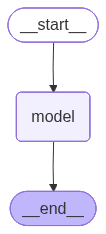

In [6]:
from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent

model=ChatAnthropic(
    model_name="claude-3-5-haiku",
    temperature=0.1,
    max_tokens_to_sample=1000,
    timeout=30
)

agent=create_agent(
    model=model,
    tools=[],
    system_prompt="You are a helpful assistant",
)

agent


### Dynamic model
Dynamic models are selected at runtime based on the current state and context. This enables sophisticated routing logic and cost optimization.
To use a dynamic model, create middleware using the @wrap_model_call decorator that modifies the model in the request:

In [ ]:
from langchain.agents import create_agent
from langchain_anthropic import ChatAnthropic
from langchain.agents.middleware import wrap_model_call,ModelRequest,ModelResponse

basic_model=ChatAnthropic(model_name="claude-haiku-4-5",temperature=0.1,max_tokens_to_sample=1000,timeout=30)
advanced_model=ChatAnthropic(model_name="claude-sonnet-4-6",temperature=0.1,max_tokens_to_sample=1000,timeout=30)

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """ Choose the model based on the prompt """

    message_count=len(request.state['messages'])

    if message_count > 10:
        model=advanced_model
    else:
        model=basic_model

    return handler(request.override(model=model))    
    

agent=create_agent(
    model=basic_model,
    tools=[],
    system_prompt="You are a helpful assistant",
    middleware=[dynamic_model_selection]
)
   

agent.invoke({"messages": [{"role": "user", "content": "what is the weather in Pune"}]})


{'messages': [HumanMessage(content='what is the weather in Pune', additional_kwargs={}, response_metadata={}, id='07fbc314-3018-4db6-b125-99938c907d45'),
  AIMessage(content='I don\'t have access to real-time weather data or the internet, so I can\'t tell you the current weather in Pune.\n\nHowever, you can check the weather in Pune using:\n\n1. **Weather websites**: Google Weather, Weather.com, AccuWeather\n2. **Weather apps**: OpenWeather, Weather Underground, your phone\'s built-in weather app\n3. **Search engines**: Simply search "Pune weather" on Google\n4. **Local sources**: India Meteorological Department (IMD) website\n\nIf you\'d like general information about Pune\'s climate or typical weather patterns for a specific season, I\'d be happy to help with that!', additional_kwargs={}, response_metadata={'id': 'msg_01Sk37nTUyWCjapWAAtwxUby', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephe